# 13 · Unstructured magnitude pruning: control and paper-inspired recovery

**Single responsibility:** study fine-grained weight pruning on the frozen Fast-80
pruning baseline without confusing mathematical sparsity with ESP32 speed.

This revision deliberately contains two branches:

1. **Global one-shot control** — exact global `|weight|` ranking followed by two masked
   recovery epochs. This preserves the original negative hardware control.
2. **Paper-inspired iterative method** — layer sensitivity changes each layer's effective
   magnitude threshold, five prune/retrain rounds preserve surviving weights, and a
   validation-controlled final recovery uses one-tenth of Fast-80's training rate.

The second branch is inspired by Han et al., not presented as an exact reproduction of
their AlexNet/VGG experiments. Fast-80 has depthwise-separable layers, BatchNorm, a binary
head, and a different dataset.

## Evidence flow

```text
Frozen Fast-80 + frozen train/validation/test split
                 │
        ┌────────┴────────┐
        │                 │
global one-shot      layer-sensitivity audit
        │                 │
  2-epoch recovery   5 × prune/retrain + early stop
        └────────┬────────┘
                 ↓
validation-only float and INT8 gates
                 ↓
      one selected deployable model
                 ↓
held-out test, storage, MACs, activation, host timing
                 ↓
exact FlatBuffer physical ESP32-CAM profile
```

The held-out test split is not used for pruning, sensitivity, threshold selection, or
candidate selection.

## Paper contract and deliberate adaptations

Primary references:

- Han et al., [*Learning both Weights and Connections for Efficient Neural Networks*](https://proceedings.neurips.cc/paper/2015/file/ae0eb3eed39d2bcef4622b2499a05fe6-Paper.pdf)
- Zhu and Gupta, [*To Prune, or Not to Prune*](https://arxiv.org/abs/1710.01878)

Han et al. establish the train → magnitude-prune → retrain procedure, preserve surviving
weights, use layer sensitivity to choose different thresholds, lower the retraining
learning rate, and repeat pruning/retraining. This notebook implements those concepts with
registered Fast-80-specific choices:

| Decision | Notebook 13 implementation |
|---|---|
| Granularity | individual Conv2D, DepthwiseConv2D, and Dense kernel scalars |
| Criterion | absolute magnitude, `|w|` |
| Layer sensitivity | validation-subset PR-AUC and BCE damage after 50% local pruning |
| Threshold policy | sensitivity-adjusted magnitude scores, exact global target |
| Iteration | five cumulative prune/retrain rounds |
| Recovery rate | `1e-5`, one-tenth of Fast-80's `1e-4` |
| Mask rule | removed connections never regrow |
| Runtime | stock dense TFLite Micro / ESP-NN; no sparse acceleration claim |

Gzip and packed sparse estimates are storage diagnostics. Only a physical-device capture
can establish latency, tensor-arena, SRAM, PSRAM, or end-to-end FPS.

## 1 · Locate the repository deterministically

In [ ]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent.parent.resolve()
assert (ROOT / "pyproject.toml").exists(), f"Repository root not found from {Path.cwd()}"
print(ROOT)

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32


## 2 · Import deterministic experiment dependencies

In [2]:
import gzip
import hashlib
import json
import math
import os
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, average_precision_score, log_loss

from vww_esp32.evaluation import (
    classification_metrics,
    expected_calibration_error,
    select_threshold,
)
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.preprocessing import make_dataset, representative_dataset, split_manifest
from vww_esp32.profiling import profile_model

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
print({
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "devices": [device.device_type for device in tf.config.list_physical_devices()],
})

{'python': '3.10.13', 'tensorflow': '2.20.0', 'devices': ['CPU']}


## 3 · Register the complete experiment before looking at results

In [3]:
SPARSITY_LEVELS = (0.25, 0.50, 0.75, 0.90)
ONE_SHOT_EPOCHS = 2
ONE_SHOT_LEARNING_RATE = 5e-5
SENSITIVITY_LOCAL_SPARSITY = 0.50
SENSITIVITY_BATCHES = 8
SENSITIVITY_PROTECTION_STRENGTH = 20.0
ITERATIVE_ROUNDS = 5
ROUND_RECOVERY_EPOCHS = 1
FINAL_RECOVERY_MAX_EPOCHS = 5
FINAL_RECOVERY_PATIENCE = 2
ITERATIVE_LEARNING_RATE = 1e-5
BATCH_SIZE = 64
IMAGE_SIZE = (80, 80)
REPRESENTATIVE_SAMPLES = 500
MINIMUM_RECALL = 0.80
MAXIMUM_F1_DROP = 0.03
HOST_WARMUPS = 20
HOST_RUNS = 100
REUSE_CACHE = os.environ.get("VWW_REUSE_PRUNING_CACHE", "0") == "1"

FLOAT_MODEL_PATH = ROOT / "artifacts/fast_80/models/final.keras"
DEPLOYED_BASELINE_TFLITE_PATH = ROOT / "artifacts/fast_80/models/vww_mobilenetv1_80_int8.tflite"
MANIFEST_PATH = ROOT / "data/processed/manifest.csv"
REFERENCE_CONTRACT_PATH = ROOT / "artifacts/pruning/reference_audit/baseline_contract.json"
BASELINE_DEVICE_DIR = ROOT / "artifacts/device_profiles/fast_80"

OUTPUT_DIR = ROOT / "artifacts/pruning/unstructured_magnitude"
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in (OUTPUT_DIR, MODEL_DIR, REPORT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

required = [FLOAT_MODEL_PATH, DEPLOYED_BASELINE_TFLITE_PATH, MANIFEST_PATH, REFERENCE_CONTRACT_PATH]
missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
assert not missing, f"Missing required inputs: {missing}"
print({"sparsities": SPARSITY_LEVELS, "reuse_cache": REUSE_CACHE})

{'sparsities': (0.25, 0.5, 0.75, 0.9), 'reuse_cache': True}


## 4 · Verify the frozen Fast-80 pruning baseline

In [4]:
def sha256_file(path: Path, chunk_bytes: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()


with REFERENCE_CONTRACT_PATH.open(encoding="utf-8") as handle:
    reference_contract = json.load(handle)

current_hashes = {
    str(FLOAT_MODEL_PATH.relative_to(ROOT)): sha256_file(FLOAT_MODEL_PATH),
    str(DEPLOYED_BASELINE_TFLITE_PATH.relative_to(ROOT)): sha256_file(DEPLOYED_BASELINE_TFLITE_PATH),
    str(MANIFEST_PATH.relative_to(ROOT)): sha256_file(MANIFEST_PATH),
}
for path, digest in current_hashes.items():
    assert reference_contract["hashes"][path] == digest, f"Frozen input changed: {path}"
display(pd.DataFrame([{"artifact": path, "sha256": digest} for path, digest in current_hashes.items()]).style.hide(axis="index"))

artifact,sha256
artifacts/fast_80/models/final.keras,1fbfb79a810f4a4efa17d3a2760fd059e0338e4d5d5121ba7998259db81a4acf
artifacts/fast_80/models/vww_mobilenetv1_80_int8.tflite,70eb89724ae7f5f84097922e481ba8c61946ef7219fdbeddabc81a612ae7691d
data/processed/manifest.csv,6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242f15517680652e38704


## 5 · Load and profile Fast-80 before constructing masks

In [5]:
baseline_model = tf.keras.models.load_model(FLOAT_MODEL_PATH, compile=False)
baseline_layers, baseline_liveness, baseline_summary = profile_model(baseline_model, batch_size=1)
assert baseline_model.count_params() == reference_contract["float_parameters"]
assert int(baseline_summary["estimated_macs_batch1"]) == reference_contract["dense_macs_batch1"]
print({
    "input": baseline_model.input_shape,
    "parameters": baseline_model.count_params(),
    "dense_macs": int(baseline_summary["estimated_macs_batch1"]),
    "tflite_live_peak_bytes": reference_contract["tflite_live_activation_peak_bytes"],
})

{'input': (None, 80, 80, 3), 'parameters': 111793, 'dense_macs': 3993536, 'tflite_live_peak_bytes': 38400}


## 6 · Load the frozen train, validation, and test partitions

In [6]:
manifest = pd.read_csv(MANIFEST_PATH)
splits = split_manifest(manifest)
train_ds = make_dataset(splits["train"], image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, training=True, seed=SEED)
val_ds = make_dataset(splits["val"], image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, training=False)
test_ds = make_dataset(splits["test"], image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, training=False)
print({name: len(frame) for name, frame in splits.items()})

{'train': 12000, 'val': 2000, 'test': 2000}


## 7 · Define threshold and evaluation helpers

In [7]:
def collect_predictions_quiet(model: tf.keras.Model, dataset) -> tuple[np.ndarray, np.ndarray]:
    labels = np.concatenate([np.asarray(label).reshape(-1) for _, label in dataset]).astype(int)
    probabilities = np.asarray(model.predict(dataset, verbose=0)).reshape(-1)
    return labels, probabilities


def evaluate_probabilities(labels: np.ndarray, probabilities: np.ndarray) -> dict[str, object]:
    threshold_result = select_threshold(
        labels,
        probabilities,
        objective="f1",
        minimum_recall=MINIMUM_RECALL,
        false_positive_cost=1.0,
        false_negative_cost=2.0,
    )
    metrics = classification_metrics(labels, probabilities, threshold_result["threshold"])
    metrics["expected_calibration_error_10_bins"] = expected_calibration_error(labels, probabilities, bins=10)
    return metrics

## 8 · Recompute the validation reference in this exact runtime

In [8]:
val_labels, baseline_val_probabilities = collect_predictions_quiet(baseline_model, val_ds)
baseline_val_metrics = evaluate_probabilities(val_labels, baseline_val_probabilities)
print({key: baseline_val_metrics[key] for key in ("threshold", "accuracy", "precision", "recall", "f1", "pr_auc")})

2026-09-19 07:49:04.143722: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


{'threshold': 0.27, 'accuracy': 0.6485, 'precision': 0.5967523680649527, 'recall': 0.8918099089989889, 'f1': 0.7150385083096878, 'pr_auc': 0.7831409453907229}


## 9 · Identify the exact fine-grained pruning domain

In [9]:
PRUNABLE_TYPES = (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D, tf.keras.layers.Dense)


def prunable_layers(model: tf.keras.Model) -> list[tf.keras.layers.Layer]:
    return [layer for layer in model.layers if isinstance(layer, PRUNABLE_TYPES)]


prunable_inventory = pd.DataFrame([
    {
        "layer": layer.name,
        "type": layer.__class__.__name__,
        "kernel_shape": "×".join(map(str, layer.kernel.shape)),
        "kernel_weights": int(np.prod(layer.kernel.shape)),
    }
    for layer in prunable_layers(baseline_model)
])
prunable_inventory.to_csv(REPORT_DIR / "prunable_tensor_inventory.csv", index=False)
print(f"{len(prunable_inventory)} kernels; {prunable_inventory['kernel_weights'].sum():,} scalar weights")
display(prunable_inventory.style.hide(axis="index"))

22 kernels; 104,944 scalar weights


layer,type,kernel_shape,kernel_weights
stem_conv,Conv2D,3×3×3×8,216
block1_dw,DepthwiseConv2D,3×3×8×1,72
block1_pw,Conv2D,1×1×8×16,128
block2_dw,DepthwiseConv2D,3×3×16×1,144
block2_pw,Conv2D,1×1×16×32,512
block3_dw,DepthwiseConv2D,3×3×32×1,288
block3_pw,Conv2D,1×1×32×32,1024
block4_dw,DepthwiseConv2D,3×3×32×1,288
block4_pw,Conv2D,1×1×32×64,2048
block5_dw,DepthwiseConv2D,3×3×64×1,576


## 10 · Implement exact masks and permanent zero enforcement

In [10]:
def split_flat_mask(model: tf.keras.Model, flat_mask: np.ndarray) -> dict[str, np.ndarray]:
    masks, offset = {}, 0
    for layer in prunable_layers(model):
        size = int(np.prod(layer.kernel.shape))
        masks[layer.name] = flat_mask[offset:offset + size].reshape(layer.kernel.shape).astype(np.float32)
        offset += size
    assert offset == flat_mask.size
    return masks


def flatten_masks(model: tf.keras.Model, masks: dict[str, np.ndarray] | None = None) -> np.ndarray:
    if masks is None:
        return np.ones(sum(int(np.prod(layer.kernel.shape)) for layer in prunable_layers(model)), dtype=np.float32)
    return np.concatenate([masks[layer.name].reshape(-1) for layer in prunable_layers(model)]).astype(np.float32)


def build_global_magnitude_masks(model: tf.keras.Model, target_sparsity: float) -> dict[str, np.ndarray]:
    magnitudes = np.concatenate([np.abs(np.asarray(layer.kernel.numpy())).reshape(-1) for layer in prunable_layers(model)])
    prune_count = int(np.floor(magnitudes.size * target_sparsity))
    order = np.argsort(magnitudes, kind="stable")
    flat_mask = np.ones(magnitudes.size, dtype=np.float32)
    flat_mask[order[:prune_count]] = 0.0
    return split_flat_mask(model, flat_mask)


def apply_masks(model: tf.keras.Model, masks: dict[str, np.ndarray]) -> None:
    for layer_name, mask in masks.items():
        layer = model.get_layer(layer_name)
        layer.kernel.assign(layer.kernel * tf.convert_to_tensor(mask, dtype=layer.kernel.dtype))


def measured_kernel_sparsity(model: tf.keras.Model) -> float:
    kernels = [np.asarray(layer.kernel.numpy()) for layer in prunable_layers(model)]
    return float(sum(np.count_nonzero(kernel == 0) for kernel in kernels) / sum(kernel.size for kernel in kernels))


class EnforceMasks(tf.keras.callbacks.Callback):
    def __init__(self, masks: dict[str, np.ndarray]):
        super().__init__()
        self.masks = masks

    def on_train_batch_end(self, batch, logs=None):
        apply_masks(self.model, self.masks)

    def on_epoch_end(self, epoch, logs=None):
        apply_masks(self.model, self.masks)

## 11 · Compile a pruned model without letting BatchNorm drift

In [11]:
def compile_for_recovery(model: tf.keras.Model, learning_rate: float) -> tf.keras.Model:
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.03),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )
    return model

## 12 · Define the global one-shot control

In [12]:
def run_one_shot_candidate(target_sparsity: float) -> tuple[dict[str, object], pd.DataFrame]:
    tag = f"s{int(round(target_sparsity * 100)):02d}"
    model = tf.keras.models.load_model(FLOAT_MODEL_PATH, compile=False)
    masks = build_global_magnitude_masks(model, target_sparsity)
    apply_masks(model, masks)
    _, immediate_probabilities = collect_predictions_quiet(model, val_ds)
    immediate = evaluate_probabilities(val_labels, immediate_probabilities)

    tf.keras.utils.set_random_seed(SEED)
    candidate_train_ds = make_dataset(splits["train"], image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, training=True, seed=SEED)
    model = compile_for_recovery(model, ONE_SHOT_LEARNING_RATE)
    started = time.perf_counter()
    history = model.fit(
        candidate_train_ds,
        validation_data=val_ds,
        epochs=ONE_SHOT_EPOCHS,
        callbacks=[EnforceMasks(masks)],
        verbose=2,
    )
    elapsed = time.perf_counter() - started
    apply_masks(model, masks)
    _, recovered_probabilities = collect_predictions_quiet(model, val_ds)
    recovered = evaluate_probabilities(val_labels, recovered_probabilities)
    actual = measured_kernel_sparsity(model)
    assert abs(actual - target_sparsity) < 1e-5

    model_path = MODEL_DIR / f"one_shot_{tag}_recovered.keras"
    mask_path = MODEL_DIR / f"one_shot_{tag}_masks.npz"
    model.save(model_path)
    np.savez_compressed(mask_path, **masks)
    detail = {
        "strategy": "one_shot_global",
        "tag": tag,
        "target_sparsity": target_sparsity,
        "actual_sparsity": actual,
        "immediate_validation": immediate,
        "recovered_validation": recovered,
        "recovery_epochs": ONE_SHOT_EPOCHS,
        "recovery_seconds": elapsed,
        "model_path": str(model_path.relative_to(ROOT)),
        "mask_path": str(mask_path.relative_to(ROOT)),
    }
    (REPORT_DIR / f"one_shot_{tag}_metrics.json").write_text(json.dumps(detail, indent=2) + "\n", encoding="utf-8")
    history_frame = pd.DataFrame(history.history)
    history_frame.insert(0, "epoch", np.arange(1, len(history_frame) + 1))
    history_frame.insert(0, "tag", tag)
    history_frame.insert(0, "strategy", "one_shot_global")
    row = {key: value for key, value in detail.items() if key not in ("immediate_validation", "recovered_validation")}
    for prefix, metrics in (("immediate", immediate), ("recovered", recovered)):
        for key, value in metrics.items():
            if key != "confusion_matrix":
                row[f"{prefix}_{key}"] = value
    del model
    tf.keras.backend.clear_session()
    return row, history_frame

## 13 · Execute or reuse the one-shot sweep

In [13]:
one_shot_csv = REPORT_DIR / "one_shot_sweep.csv"
one_shot_history_csv = REPORT_DIR / "one_shot_recovery_history.csv"
one_shot_cache_ready = one_shot_csv.exists() and one_shot_history_csv.exists() and all(
    (MODEL_DIR / f"one_shot_s{int(level * 100):02d}_recovered.keras").exists() for level in SPARSITY_LEVELS
)
if REUSE_CACHE and one_shot_cache_ready:
    one_shot_sweep = pd.read_csv(one_shot_csv)
    one_shot_history = pd.read_csv(one_shot_history_csv)
    print("Reused one-shot cache")
else:
    rows, histories = [], []
    for target in SPARSITY_LEVELS:
        print(f"\n=== One-shot target {target:.0%} ===")
        row, history = run_one_shot_candidate(target)
        rows.append(row)
        histories.append(history)
    one_shot_sweep = pd.DataFrame(rows).sort_values("target_sparsity").reset_index(drop=True)
    one_shot_history = pd.concat(histories, ignore_index=True)
    one_shot_sweep.to_csv(one_shot_csv, index=False)
    one_shot_history.to_csv(one_shot_history_csv, index=False)
display(one_shot_sweep[["tag", "actual_sparsity", "immediate_f1", "recovered_f1", "recovered_recall", "recovered_pr_auc"]].style.hide(axis="index").format({
    "actual_sparsity": "{:.1%}", "immediate_f1": "{:.3f}", "recovered_f1": "{:.3f}", "recovered_recall": "{:.3f}", "recovered_pr_auc": "{:.3f}"
}))

Reused one-shot cache


tag,actual_sparsity,immediate_f1,recovered_f1,recovered_recall,recovered_pr_auc
s25,25.0%,0.715,0.716,0.819,0.781
s50,50.0%,0.694,0.715,0.831,0.758
s75,75.0%,0.662,0.662,1.000,0.494
s90,90.0%,0.662,0.662,1.000,0.494


## 14 · Measure layer sensitivity before assigning paper-inspired thresholds

In [14]:
sensitivity_csv = REPORT_DIR / "layer_sensitivity.csv"
if REUSE_CACHE and sensitivity_csv.exists():
    layer_sensitivity = pd.read_csv(sensitivity_csv)
    print("Reused layer sensitivity cache")
else:
    sensitivity_ds = val_ds.take(SENSITIVITY_BATCHES)
    sensitivity_labels, sensitivity_baseline_probabilities = collect_predictions_quiet(baseline_model, sensitivity_ds)
    baseline_probe_pr_auc = average_precision_score(sensitivity_labels, sensitivity_baseline_probabilities)
    baseline_probe_loss = log_loss(sensitivity_labels, np.clip(sensitivity_baseline_probabilities, 1e-7, 1 - 1e-7))
    rows = []
    for layer in prunable_layers(baseline_model):
        original = np.asarray(layer.kernel.numpy()).copy()
        flat = np.abs(original).reshape(-1)
        prune_count = int(np.floor(flat.size * SENSITIVITY_LOCAL_SPARSITY))
        local_mask = np.ones(flat.size, dtype=np.float32)
        local_mask[np.argsort(flat, kind="stable")[:prune_count]] = 0.0
        layer.kernel.assign(original * local_mask.reshape(original.shape))
        _, probabilities = collect_predictions_quiet(baseline_model, sensitivity_ds)
        pr_auc = average_precision_score(sensitivity_labels, probabilities)
        loss = log_loss(sensitivity_labels, np.clip(probabilities, 1e-7, 1 - 1e-7))
        layer.kernel.assign(original)
        rows.append({
            "layer": layer.name,
            "type": layer.__class__.__name__,
            "kernel_weights": flat.size,
            "probe_sparsity": SENSITIVITY_LOCAL_SPARSITY,
            "baseline_pr_auc": baseline_probe_pr_auc,
            "pruned_pr_auc": pr_auc,
            "pr_auc_drop": max(0.0, baseline_probe_pr_auc - pr_auc),
            "baseline_bce": baseline_probe_loss,
            "pruned_bce": loss,
            "relative_bce_increase": max(0.0, (loss - baseline_probe_loss) / max(baseline_probe_loss, 1e-8)),
        })
    layer_sensitivity = pd.DataFrame(rows)
    layer_sensitivity["risk_raw"] = layer_sensitivity["pr_auc_drop"] + 0.25 * layer_sensitivity["relative_bce_increase"]
    maximum_risk = max(float(layer_sensitivity["risk_raw"].max()), 1e-12)
    layer_sensitivity["risk_normalized"] = layer_sensitivity["risk_raw"] / maximum_risk
    layer_sensitivity["protection_multiplier"] = 1.0 + SENSITIVITY_PROTECTION_STRENGTH * layer_sensitivity["risk_normalized"]
    layer_sensitivity.to_csv(sensitivity_csv, index=False)
layer_protection = dict(zip(layer_sensitivity["layer"], layer_sensitivity["protection_multiplier"]))
display(layer_sensitivity.sort_values("risk_raw", ascending=False).style.hide(axis="index").format({
    "probe_sparsity": "{:.0%}", "baseline_pr_auc": "{:.3f}", "pruned_pr_auc": "{:.3f}", "pr_auc_drop": "{:.3f}",
    "baseline_bce": "{:.3f}", "pruned_bce": "{:.3f}", "relative_bce_increase": "{:.1%}", "risk_raw": "{:.3f}",
    "risk_normalized": "{:.2f}", "protection_multiplier": "{:.1f}×"
}))

Reused layer sensitivity cache


layer,type,kernel_weights,probe_sparsity,baseline_pr_auc,pruned_pr_auc,pr_auc_drop,baseline_bce,pruned_bce,relative_bce_increase,risk_raw,risk_normalized,protection_multiplier
stem_conv,Conv2D,216,50%,0.804,0.684,0.121,0.547,0.740,35.4%,0.209,1.00,21.0×
block1_dw,DepthwiseConv2D,72,50%,0.804,0.737,0.067,0.547,0.603,10.4%,0.093,0.44,9.9×
block1_pw,Conv2D,128,50%,0.804,0.749,0.055,0.547,0.609,11.4%,0.083,0.40,9.0×
block5_pw,Conv2D,4096,50%,0.804,0.778,0.026,0.547,0.603,10.2%,0.051,0.25,5.9×
block2_pw,Conv2D,512,50%,0.804,0.785,0.020,0.547,0.576,5.3%,0.033,0.16,4.2×
block2_dw,DepthwiseConv2D,144,50%,0.804,0.788,0.016,0.547,0.579,6.0%,0.031,0.15,4.0×
block3_pw,Conv2D,1024,50%,0.804,0.789,0.015,0.547,0.575,5.1%,0.027,0.13,3.6×
block3_dw,DepthwiseConv2D,288,50%,0.804,0.787,0.017,0.547,0.561,2.6%,0.023,0.11,3.2×
block4_dw,DepthwiseConv2D,288,50%,0.804,0.792,0.012,0.547,0.560,2.4%,0.018,0.09,2.7×
block6_dw,DepthwiseConv2D,576,50%,0.804,0.797,0.007,0.547,0.557,1.8%,0.012,0.06,2.1×


## 15 · Visualize which layers require smaller effective thresholds

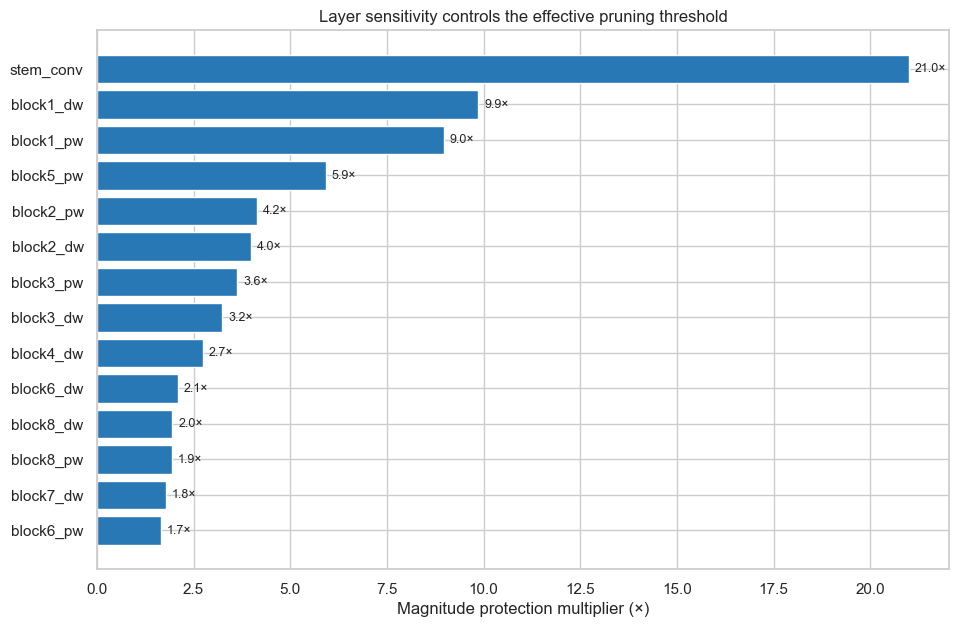

artifacts/pruning/unstructured_magnitude/figures/layer_sensitivity_protection.png


In [15]:
sensitivity_plot = layer_sensitivity.sort_values("protection_multiplier").tail(14)
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(sensitivity_plot["layer"], sensitivity_plot["protection_multiplier"], color="#2878B5")
ax.set(title="Layer sensitivity controls the effective pruning threshold", xlabel="Magnitude protection multiplier (×)", ylabel="")
for bar, value in zip(bars, sensitivity_plot["protection_multiplier"]):
    ax.text(value + 0.15, bar.get_y() + bar.get_height() / 2, f"{value:.1f}×", va="center", fontsize=9)
figure_path = FIGURE_DIR / "layer_sensitivity_protection.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 16 · Extend masks using sensitivity-adjusted magnitude scores

In [16]:
def extend_sensitivity_adjusted_masks(
    model: tf.keras.Model,
    target_sparsity: float,
    current_masks: dict[str, np.ndarray] | None,
    protection: dict[str, float],
) -> dict[str, np.ndarray]:
    current_flat = flatten_masks(model, current_masks)
    adjusted_scores = []
    for layer in prunable_layers(model):
        magnitude = np.abs(np.asarray(layer.kernel.numpy())).reshape(-1)
        adjusted_scores.append(magnitude * float(protection[layer.name]))
    scores = np.concatenate(adjusted_scores)
    total = scores.size
    desired_zeros = int(np.floor(total * target_sparsity))
    current_zeros = int(np.count_nonzero(current_flat == 0))
    new_prune_count = max(0, desired_zeros - current_zeros)
    scores[current_flat == 0] = np.inf
    active_order = np.argsort(scores, kind="stable")
    current_flat[active_order[:new_prune_count]] = 0.0
    masks = split_flat_mask(model, current_flat)
    assert np.count_nonzero(current_flat == 0) == desired_zeros
    return masks

## 17 · Define five-round paper-inspired prune/retrain

In [17]:
def run_iterative_candidate(target_sparsity: float) -> tuple[dict[str, object], pd.DataFrame]:
    tag = f"s{int(round(target_sparsity * 100)):02d}"
    model = tf.keras.models.load_model(FLOAT_MODEL_PATH, compile=False)
    model = compile_for_recovery(model, ITERATIVE_LEARNING_RATE)
    masks = None
    round_rows = []
    tf.keras.utils.set_random_seed(SEED)
    candidate_train_ds = make_dataset(splits["train"], image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, training=True, seed=SEED)
    started = time.perf_counter()

    for round_index, cumulative_target in enumerate(np.linspace(target_sparsity / ITERATIVE_ROUNDS, target_sparsity, ITERATIVE_ROUNDS), start=1):
        masks = extend_sensitivity_adjusted_masks(model, float(cumulative_target), masks, layer_protection)
        apply_masks(model, masks)
        _, immediate_probabilities = collect_predictions_quiet(model, val_ds)
        immediate = evaluate_probabilities(val_labels, immediate_probabilities)
        history = model.fit(
            candidate_train_ds,
            validation_data=val_ds,
            epochs=ROUND_RECOVERY_EPOCHS,
            callbacks=[EnforceMasks(masks)],
            verbose=0,
        )
        apply_masks(model, masks)
        _, recovered_probabilities = collect_predictions_quiet(model, val_ds)
        recovered = evaluate_probabilities(val_labels, recovered_probabilities)
        round_rows.append({
            "strategy": "paper_iterative",
            "tag": tag,
            "round": round_index,
            "cumulative_target": float(cumulative_target),
            "actual_sparsity": measured_kernel_sparsity(model),
            "immediate_f1": immediate["f1"],
            "immediate_pr_auc": immediate["pr_auc"],
            "recovered_f1": recovered["f1"],
            "recovered_pr_auc": recovered["pr_auc"],
            "train_loss": history.history["loss"][-1],
            "val_pr_auc_fit": history.history["val_pr_auc"][-1],
        })

    _, final_immediate_probabilities = collect_predictions_quiet(model, val_ds)
    final_immediate = evaluate_probabilities(val_labels, final_immediate_probabilities)
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=FINAL_RECOVERY_PATIENCE,
        restore_best_weights=True,
    )
    final_history = model.fit(
        candidate_train_ds,
        validation_data=val_ds,
        epochs=FINAL_RECOVERY_MAX_EPOCHS,
        callbacks=[EnforceMasks(masks), early_stop],
        verbose=2,
    )
    apply_masks(model, masks)
    elapsed = time.perf_counter() - started
    _, recovered_probabilities = collect_predictions_quiet(model, val_ds)
    recovered = evaluate_probabilities(val_labels, recovered_probabilities)
    actual = measured_kernel_sparsity(model)
    assert abs(actual - target_sparsity) < 1e-5

    model_path = MODEL_DIR / f"iterative_{tag}_recovered.keras"
    mask_path = MODEL_DIR / f"iterative_{tag}_masks.npz"
    model.save(model_path)
    np.savez_compressed(mask_path, **masks)
    detail = {
        "strategy": "paper_iterative",
        "tag": tag,
        "target_sparsity": target_sparsity,
        "actual_sparsity": actual,
        "immediate_validation": final_immediate,
        "recovered_validation": recovered,
        "prune_retrain_rounds": ITERATIVE_ROUNDS,
        "final_recovery_epochs": len(final_history.history["loss"]),
        "recovery_seconds": elapsed,
        "model_path": str(model_path.relative_to(ROOT)),
        "mask_path": str(mask_path.relative_to(ROOT)),
    }
    (REPORT_DIR / f"iterative_{tag}_metrics.json").write_text(json.dumps(detail, indent=2) + "\n", encoding="utf-8")
    row = {key: value for key, value in detail.items() if key not in ("immediate_validation", "recovered_validation")}
    for prefix, metrics in (("immediate", final_immediate), ("recovered", recovered)):
        for key, value in metrics.items():
            if key != "confusion_matrix":
                row[f"{prefix}_{key}"] = value
    del model
    tf.keras.backend.clear_session()
    return row, pd.DataFrame(round_rows)

## 18 · Execute or reuse the iterative sweep

In [18]:
iterative_csv = REPORT_DIR / "iterative_sweep.csv"
iterative_round_csv = REPORT_DIR / "iterative_round_history.csv"
iterative_cache_ready = iterative_csv.exists() and iterative_round_csv.exists() and all(
    (MODEL_DIR / f"iterative_s{int(level * 100):02d}_recovered.keras").exists() for level in SPARSITY_LEVELS
)
if REUSE_CACHE and iterative_cache_ready:
    iterative_sweep = pd.read_csv(iterative_csv)
    iterative_round_history = pd.read_csv(iterative_round_csv)
    print("Reused iterative cache")
else:
    rows, round_frames = [], []
    for target in SPARSITY_LEVELS:
        print(f"\n=== Paper-inspired iterative target {target:.0%} ===")
        row, rounds = run_iterative_candidate(target)
        rows.append(row)
        round_frames.append(rounds)
    iterative_sweep = pd.DataFrame(rows).sort_values("target_sparsity").reset_index(drop=True)
    iterative_round_history = pd.concat(round_frames, ignore_index=True)
    iterative_sweep.to_csv(iterative_csv, index=False)
    iterative_round_history.to_csv(iterative_round_csv, index=False)
display(iterative_sweep[["tag", "actual_sparsity", "immediate_f1", "recovered_f1", "recovered_recall", "recovered_pr_auc", "final_recovery_epochs"]].style.hide(axis="index").format({
    "actual_sparsity": "{:.1%}", "immediate_f1": "{:.3f}", "recovered_f1": "{:.3f}", "recovered_recall": "{:.3f}", "recovered_pr_auc": "{:.3f}"
}))

Reused iterative cache


tag,actual_sparsity,immediate_f1,recovered_f1,recovered_recall,recovered_pr_auc,final_recovery_epochs
s25,25.0%,0.719,0.719,0.807,0.782,3
s50,50.0%,0.718,0.716,0.836,0.767,3
s75,75.0%,0.662,0.662,1.000,0.494,3
s90,90.0%,0.662,0.662,1.000,0.494,3


## 19 · Compare one-shot and iterative validation quality

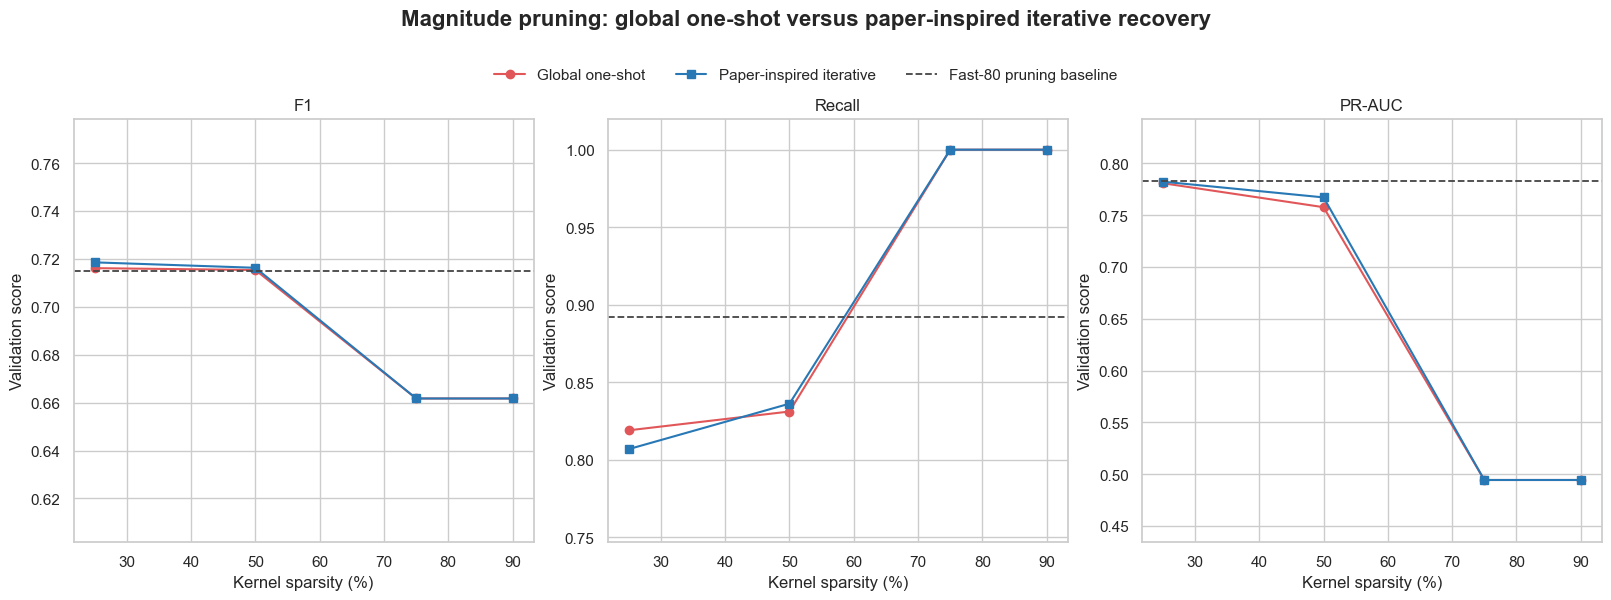

artifacts/pruning/unstructured_magnitude/figures/one_shot_vs_iterative_quality.png


In [19]:
float_sweep = pd.concat([one_shot_sweep, iterative_sweep], ignore_index=True)
float_sweep["f1_drop_vs_baseline"] = baseline_val_metrics["f1"] - float_sweep["recovered_f1"]
float_sweep["recall_gate"] = float_sweep["recovered_recall"] >= MINIMUM_RECALL
float_sweep["f1_gate"] = float_sweep["f1_drop_vs_baseline"] <= MAXIMUM_F1_DROP
float_sweep["eligible_float"] = float_sweep["recall_gate"] & float_sweep["f1_gate"]
float_sweep.to_csv(REPORT_DIR / "float_strategy_comparison.csv", index=False)

labels = {"one_shot_global": "Global one-shot", "paper_iterative": "Paper-inspired iterative"}
colors = {"one_shot_global": "#E15759", "paper_iterative": "#2878B5"}
markers = {"one_shot_global": "o", "paper_iterative": "s"}
metrics = [("recovered_f1", "F1"), ("recovered_recall", "Recall"), ("recovered_pr_auc", "PR-AUC")]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for ax, (metric, title) in zip(axes, metrics):
    for strategy, group in float_sweep.groupby("strategy"):
        ax.plot(group["actual_sparsity"] * 100, group[metric], marker=markers[strategy], color=colors[strategy], label=labels[strategy])
    ax.axhline(baseline_val_metrics[metric.replace("recovered_", "")], color="#444444", linewidth=1.3, linestyle="--", label="Fast-80 pruning baseline")
    values = np.r_[float_sweep[metric], baseline_val_metrics[metric.replace("recovered_", "")]]
    ax.set(title=title, xlabel="Kernel sparsity (%)", ylabel="Validation score", ylim=(max(0, values.min() - 0.06), min(1.02, values.max() + 0.06)))
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False)
fig.suptitle("Magnitude pruning: global one-shot versus paper-inspired iterative recovery", fontsize=16, weight="bold", y=1.17)
figure_path = FIGURE_DIR / "one_shot_vs_iterative_quality.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 20 · Visualize recovery after every iterative pruning event

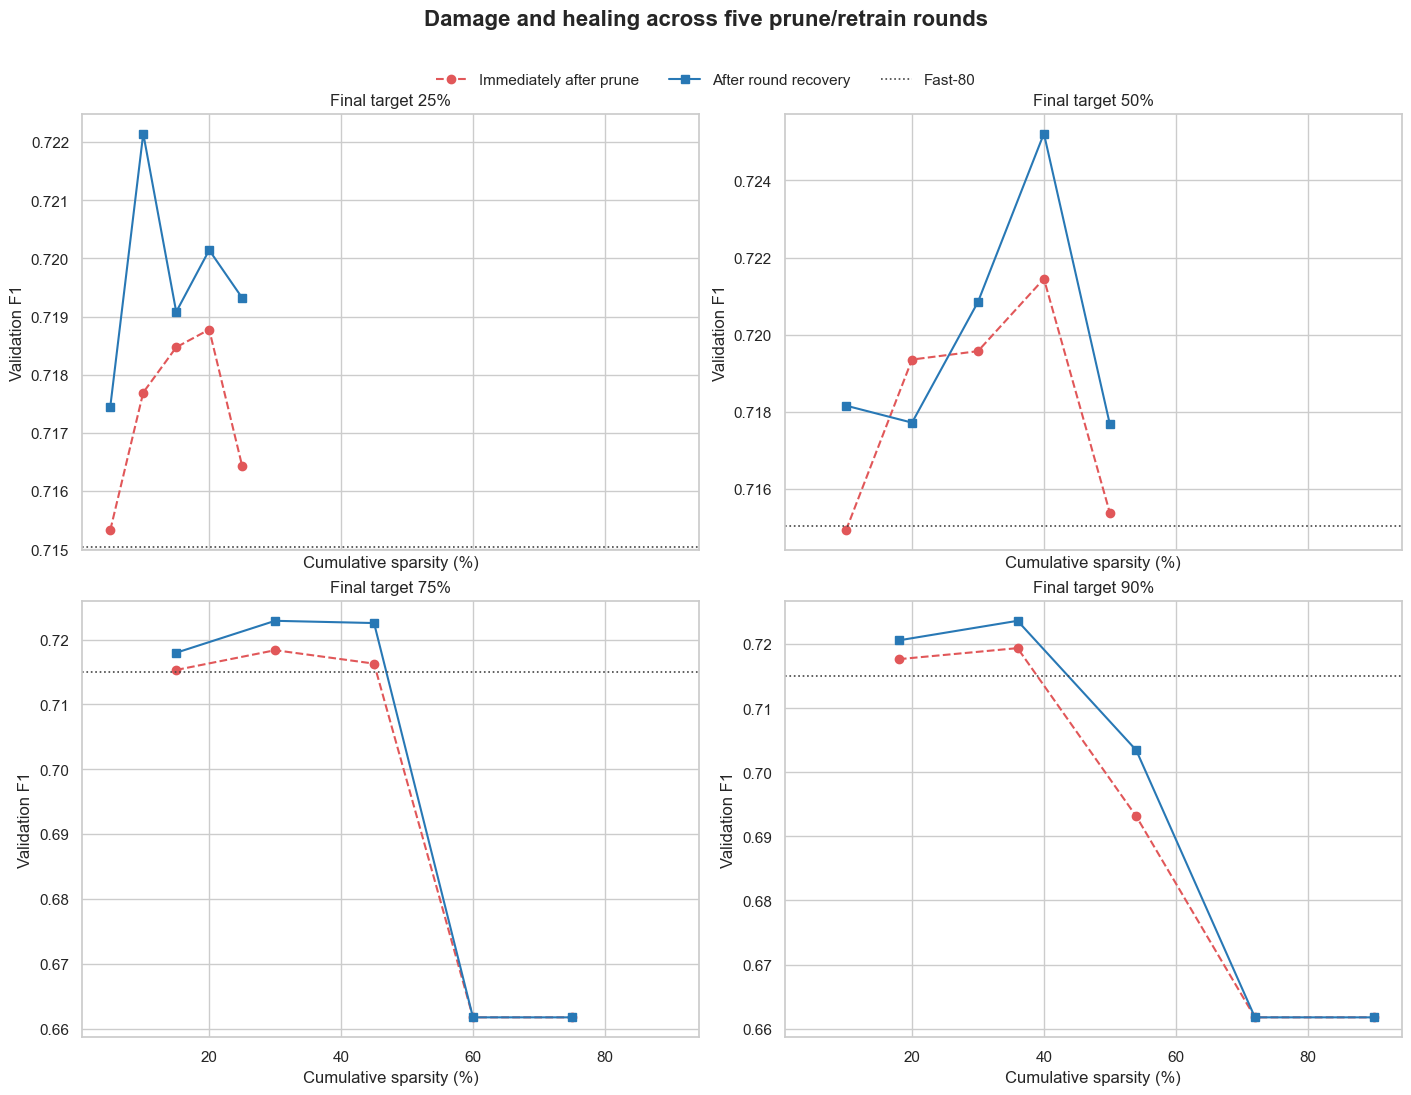

artifacts/pruning/unstructured_magnitude/figures/iterative_round_recovery.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True, sharex=True)
for ax, (tag, group) in zip(axes.flat, iterative_round_history.groupby("tag", sort=True)):
    ax.plot(group["cumulative_target"] * 100, group["immediate_f1"], "o--", color="#E15759", label="Immediately after prune")
    ax.plot(group["cumulative_target"] * 100, group["recovered_f1"], "s-", color="#2878B5", label="After round recovery")
    ax.axhline(baseline_val_metrics["f1"], color="#444444", linewidth=1.2, linestyle=":", label="Fast-80")
    ax.set(title=f"Final target {tag[1:]}%", xlabel="Cumulative sparsity (%)", ylabel="Validation F1")
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 1.03), ncol=3, frameon=False)
fig.suptitle("Damage and healing across five prune/retrain rounds", fontsize=16, weight="bold", y=1.08)
figure_path = FIGURE_DIR / "iterative_round_recovery.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 21 · Compare where each policy places zeros

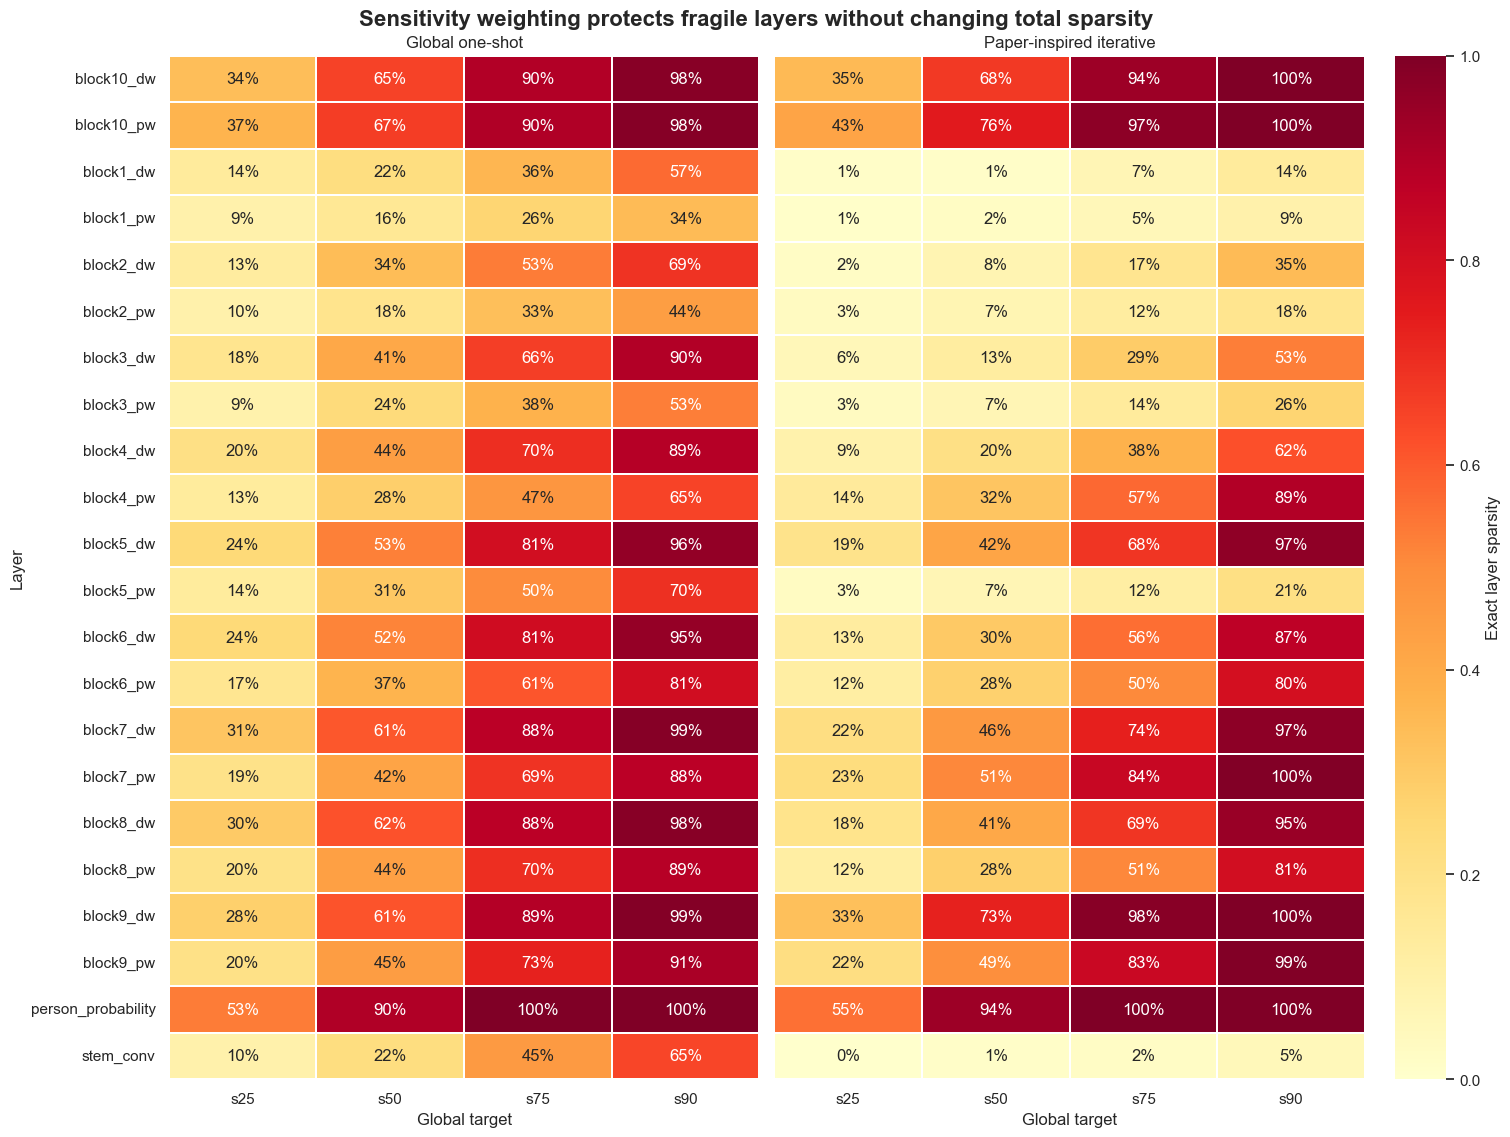

artifacts/pruning/unstructured_magnitude/figures/layer_sparsity_policy_comparison.png


In [21]:
layer_sparsity_rows = []
for strategy, prefix in (("one_shot_global", "one_shot"), ("paper_iterative", "iterative")):
    for target in SPARSITY_LEVELS:
        tag = f"s{int(target * 100):02d}"
        model = tf.keras.models.load_model(MODEL_DIR / f"{prefix}_{tag}_recovered.keras", compile=False)
        for layer in prunable_layers(model):
            kernel = np.asarray(layer.kernel.numpy())
            layer_sparsity_rows.append({"strategy": strategy, "tag": tag, "layer": layer.name, "layer_sparsity": float(np.mean(kernel == 0)), "kernel_weights": kernel.size})
        del model
layer_sparsity = pd.DataFrame(layer_sparsity_rows)
layer_sparsity.to_csv(REPORT_DIR / "layer_sparsity_by_strategy.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 11), constrained_layout=True, sharey=True)
for ax, strategy in zip(axes, ("one_shot_global", "paper_iterative")):
    matrix = layer_sparsity[layer_sparsity["strategy"] == strategy].pivot(index="layer", columns="tag", values="layer_sparsity")
    sns.heatmap(matrix, cmap="YlOrRd", vmin=0, vmax=1, annot=True, fmt=".0%", linewidths=0.3, cbar=strategy == "paper_iterative", cbar_kws={"label": "Exact layer sparsity"}, ax=ax)
    ax.set(title=labels[strategy], xlabel="Global target", ylabel="" if strategy == "paper_iterative" else "Layer")
fig.suptitle("Sensitivity weighting protects fragile layers without changing total sparsity", fontsize=16, weight="bold", y=1.02)
figure_path = FIGURE_DIR / "layer_sparsity_policy_comparison.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 22 · Export the baseline and every candidate through one identical full-INT8 path

In [22]:
export_specs = [{"strategy": "baseline", "tag": "s00", "target_sparsity": 0.0, "keras_path": FLOAT_MODEL_PATH}]
for row in float_sweep.itertuples(index=False):
    export_specs.append({"strategy": row.strategy, "tag": row.tag, "target_sparsity": row.target_sparsity, "keras_path": ROOT / row.model_path})

export_rows, model_paths = [], {}
for spec in export_specs:
    export_key = f"{spec['strategy']}__{spec['tag']}"
    if spec["strategy"] == "baseline":
        tflite_path = MODEL_DIR / "fast80_control_reexport_int8.tflite"
    else:
        prefix = "one_shot" if spec["strategy"] == "one_shot_global" else "iterative"
        tflite_path = MODEL_DIR / f"{prefix}_{spec['tag']}_int8.tflite"
    if not (REUSE_CACHE and tflite_path.exists()):
        candidate_model = tf.keras.models.load_model(spec["keras_path"], compile=False)
        representative = representative_dataset(splits["train"], image_size=IMAGE_SIZE, samples=REPRESENTATIVE_SAMPLES, seed=SEED)
        convert_full_integer(candidate_model, representative, tflite_path)
        del candidate_model
        tf.keras.backend.clear_session()
    info = inspect_tflite(tflite_path)
    assert info["input"]["dtype"] == "int8" and info["output"]["dtype"] == "int8"
    model_paths[export_key] = tflite_path
    export_rows.append({
        "export_key": export_key,
        "strategy": spec["strategy"],
        "tag": spec["tag"],
        "target_sparsity": spec["target_sparsity"],
        "tflite_path": str(tflite_path.relative_to(ROOT)),
        "tflite_bytes": tflite_path.stat().st_size,
        "gzip_bytes": len(gzip.compress(tflite_path.read_bytes(), compresslevel=9)),
        "operators": len(info["operators"]),
        "input_dtype": info["input"]["dtype"],
        "output_dtype": info["output"]["dtype"],
        "sha256": sha256_file(tflite_path),
    })
exports = pd.DataFrame(export_rows)
exports.to_csv(REPORT_DIR / "int8_export_inventory.csv", index=False)
display(exports.style.hide(axis="index").format({"target_sparsity": "{:.0%}", "tflite_bytes": "{:,}", "gzip_bytes": "{:,}"}))

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


export_key,strategy,tag,target_sparsity,tflite_path,tflite_bytes,gzip_bytes,operators,input_dtype,output_dtype,sha256
baseline__s00,baseline,s00,0%,artifacts/pruning/unstructured_magnitude/models/fast80_control_reexport_int8.tflite,"167,976","125,325",7,int8,int8,70eb89724ae7f5f84097922e481ba8c61946ef7219fdbeddabc81a612ae7691d
one_shot_global__s25,one_shot_global,s25,25%,artifacts/pruning/unstructured_magnitude/models/one_shot_s25_int8.tflite,"167,976","112,332",7,int8,int8,284a2fee84ae46f72a96dd9731b3324e4b2149fa0027c9587ae551e9f9eff968
one_shot_global__s50,one_shot_global,s50,50%,artifacts/pruning/unstructured_magnitude/models/one_shot_s50_int8.tflite,"167,976","92,368",7,int8,int8,16dce4b15cdb04b25ac9525c9f967236153eab13f55c7dae23fe4f2b8f593ea0
one_shot_global__s75,one_shot_global,s75,75%,artifacts/pruning/unstructured_magnitude/models/one_shot_s75_int8.tflite,"167,976","63,943",7,int8,int8,859d5e68ada75473ce31ba7ff339bbd5664092d55743379b52da87f3f8db878b
one_shot_global__s90,one_shot_global,s90,90%,artifacts/pruning/unstructured_magnitude/models/one_shot_s90_int8.tflite,"167,976","41,000",7,int8,int8,fd998957b42084a34f90b359cef498d7bc9920d909b1ad64dd9f4982302918cd
paper_iterative__s25,paper_iterative,s25,25%,artifacts/pruning/unstructured_magnitude/models/iterative_s25_int8.tflite,"167,976","111,949",7,int8,int8,69b09025e5aae81dac839ac0f41bdb521c25cd878def201339eea06add917b4f
paper_iterative__s50,paper_iterative,s50,50%,artifacts/pruning/unstructured_magnitude/models/iterative_s50_int8.tflite,"167,976","90,900",7,int8,int8,6832bbc709da690c59fe67ed68304113e684683f8e46c5ac65aea6ce8a0b58fb
paper_iterative__s75,paper_iterative,s75,75%,artifacts/pruning/unstructured_magnitude/models/iterative_s75_int8.tflite,"167,976","60,922",7,int8,int8,b5d240d8594da55321043c561ede3ebdfdd0ec65310bf8aacfb7630ba94da122
paper_iterative__s90,paper_iterative,s90,90%,artifacts/pruning/unstructured_magnitude/models/iterative_s90_int8.tflite,"166,816","37,128",7,int8,int8,4388b552a30048c3e34541922b22fa43c9c5ee87dee54540a8319b8da868f1e3


## 23 · Evaluate every INT8 candidate on validation before selection

In [23]:
def collect_tflite_predictions(model_path: Path, dataset) -> tuple[np.ndarray, np.ndarray]:
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    input_scale, input_zero = input_detail["quantization"]
    output_scale, output_zero = output_detail["quantization"]
    labels_out, probabilities = [], []
    for image_batch, label_batch in dataset:
        labels_out.extend(np.asarray(label_batch).reshape(-1).astype(int).tolist())
        for image in np.asarray(image_batch):
            quantized = np.clip(np.round(image / input_scale + input_zero), -128, 127).astype(np.int8)[None, ...]
            interpreter.set_tensor(input_detail["index"], quantized)
            interpreter.invoke()
            raw = interpreter.get_tensor(output_detail["index"])[0, 0]
            probabilities.append((float(raw) - output_zero) * output_scale)
    return np.asarray(labels_out), np.asarray(probabilities)


int8_rows, int8_validation_details = [], {}
for row in exports.itertuples(index=False):
    labels_out, probabilities = collect_tflite_predictions(ROOT / row.tflite_path, val_ds)
    metrics = evaluate_probabilities(labels_out, probabilities)
    int8_validation_details[row.export_key] = metrics
    int8_rows.append({
        "export_key": row.export_key,
        "strategy": row.strategy,
        "tag": row.tag,
        "target_sparsity": row.target_sparsity,
        **{key: metrics[key] for key in ("threshold", "accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "pr_auc", "predicted_positive_rate", "expected_calibration_error_10_bins")},
    })
int8_metrics = pd.DataFrame(int8_rows)
int8_metrics.to_csv(REPORT_DIR / "int8_validation_metrics.csv", index=False)
(REPORT_DIR / "int8_validation_metrics.json").write_text(json.dumps(int8_validation_details, indent=2) + "\n", encoding="utf-8")
display(int8_metrics.style.hide(axis="index").format({key: "{:.3f}" for key in ("threshold", "accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "pr_auc", "predicted_positive_rate", "expected_calibration_error_10_bins")}))

2026-09-19 07:49:10.153431: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


2026-09-19 07:49:12.789237: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


...

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


2026-09-19 07:49:17.859655: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


export_key,strategy,tag,target_sparsity,threshold,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,predicted_positive_rate,expected_calibration_error_10_bins
baseline__s00,baseline,s00,0.000000,0.335,0.671,0.626,0.832,0.513,0.714,0.775,0.781,0.657,0.025
one_shot_global__s25,one_shot_global,s25,0.250000,0.355,0.680,0.639,0.813,0.551,0.716,0.773,0.778,0.629,0.032
one_shot_global__s50,one_shot_global,s50,0.500000,0.385,0.674,0.628,0.835,0.516,0.717,0.759,0.756,0.657,0.022
one_shot_global__s75,one_shot_global,s75,0.750000,0.010,0.494,0.494,1.000,0.000,0.662,0.500,0.494,1.000,0.006
one_shot_global__s90,one_shot_global,s90,0.900000,0.010,0.494,0.494,1.000,0.000,0.662,0.500,0.494,1.000,0.006
paper_iterative__s25,paper_iterative,s25,0.250000,0.360,0.677,0.633,0.827,0.531,0.717,0.776,0.781,0.646,0.029
paper_iterative__s50,paper_iterative,s50,0.500000,0.470,0.674,0.630,0.830,0.522,0.716,0.774,0.765,0.652,0.103
paper_iterative__s75,paper_iterative,s75,0.750000,0.010,0.494,0.494,1.000,0.000,0.662,0.500,0.494,1.000,0.006
paper_iterative__s90,paper_iterative,s90,0.900000,0.010,0.494,0.494,1.000,0.000,0.662,0.500,0.494,1.000,0.006


## 24 · Select the deployable paper-inspired candidate using INT8 validation gates

In [24]:
baseline_int8_val = int8_metrics[int8_metrics["strategy"] == "baseline"].iloc[0]
iterative_int8 = int8_metrics[int8_metrics["strategy"] == "paper_iterative"].copy()
iterative_int8["f1_drop_vs_baseline"] = baseline_int8_val["f1"] - iterative_int8["f1"]
iterative_int8["recall_gate"] = iterative_int8["recall"] >= MINIMUM_RECALL
iterative_int8["f1_gate"] = iterative_int8["f1_drop_vs_baseline"] <= MAXIMUM_F1_DROP
iterative_int8["eligible"] = iterative_int8["recall_gate"] & iterative_int8["f1_gate"]
if iterative_int8["eligible"].any():
    selected_int8_row = iterative_int8[iterative_int8["eligible"]].sort_values(["target_sparsity", "f1"], ascending=[False, False]).iloc[0]
    selection_reason = "highest paper-inspired sparsity satisfying INT8 validation recall and F1 gates"
else:
    selected_int8_row = iterative_int8.sort_values(["f1", "target_sparsity"], ascending=[False, False]).iloc[0]
    selection_reason = "fallback: strongest paper-inspired INT8 validation F1"

SELECTED_TAG = str(selected_int8_row["tag"])
SELECTED_SPARSITY = float(selected_int8_row["target_sparsity"])
SELECTED_EXPORT_KEY = str(selected_int8_row["export_key"])
SELECTED_TFLITE_PATH = ROOT / exports.set_index("export_key").loc[SELECTED_EXPORT_KEY, "tflite_path"]
SELECTED_FLOAT_PATH = MODEL_DIR / f"iterative_{SELECTED_TAG}_recovered.keras"
selected_float_row = iterative_sweep.set_index("tag").loc[SELECTED_TAG]
print({"selected": SELECTED_EXPORT_KEY, "sparsity": SELECTED_SPARSITY, "reason": selection_reason, "tflite": str(SELECTED_TFLITE_PATH.relative_to(ROOT))})
display(iterative_int8[["tag", "target_sparsity", "f1", "recall", "pr_auc", "f1_drop_vs_baseline", "eligible"]].style.hide(axis="index").format({
    "target_sparsity": "{:.0%}", "f1": "{:.3f}", "recall": "{:.3f}", "pr_auc": "{:.3f}", "f1_drop_vs_baseline": "{:+.3f}"
}))

{'selected': 'paper_iterative__s50', 'sparsity': 0.5, 'reason': 'highest paper-inspired sparsity satisfying INT8 validation recall and F1 gates', 'tflite': 'artifacts/pruning/unstructured_magnitude/models/iterative_s50_int8.tflite'}


tag,target_sparsity,f1,recall,pr_auc,f1_drop_vs_baseline,eligible
s25,25%,0.717,0.827,0.781,-0.003,True
s50,50%,0.716,0.830,0.765,-0.002,True
s75,75%,0.662,1.000,0.494,+0.053,False
s90,90%,0.662,1.000,0.494,+0.053,False


## 25 · Open the held-out test exactly once after selection

In [25]:
baseline_control_tflite = model_paths["baseline__s00"]
test_labels, baseline_test_probabilities = collect_tflite_predictions(baseline_control_tflite, test_ds)
_, selected_test_probabilities = collect_tflite_predictions(SELECTED_TFLITE_PATH, test_ds)
baseline_test_metrics = classification_metrics(test_labels, baseline_test_probabilities, float(baseline_int8_val["threshold"]))
baseline_test_metrics["expected_calibration_error_10_bins"] = expected_calibration_error(test_labels, baseline_test_probabilities, bins=10)
selected_test_metrics = classification_metrics(test_labels, selected_test_probabilities, float(selected_int8_row["threshold"]))
selected_test_metrics["expected_calibration_error_10_bins"] = expected_calibration_error(test_labels, selected_test_probabilities, bins=10)
selected_float_model = tf.keras.models.load_model(SELECTED_FLOAT_PATH, compile=False)
_, selected_float_test_probabilities = collect_predictions_quiet(selected_float_model, test_ds)
selected_test_metrics["mean_absolute_probability_delta_vs_float"] = float(np.mean(np.abs(selected_test_probabilities - selected_float_test_probabilities)))
test_details = {"baseline_int8": baseline_test_metrics, "selected_int8": selected_test_metrics}
(REPORT_DIR / "selected_int8_test_metrics.json").write_text(json.dumps(test_details, indent=2) + "\n", encoding="utf-8")
display(pd.DataFrame([
    {"model": "Fast-80 pruning baseline INT8", **{key: baseline_test_metrics[key] for key in ("threshold", "accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "pr_auc")}},
    {"model": f"Paper-inspired {SELECTED_TAG} INT8", **{key: selected_test_metrics[key] for key in ("threshold", "accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "pr_auc")}},
]).style.hide(axis="index").format({key: "{:.3f}" for key in ("threshold", "accuracy", "precision", "recall", "specificity", "f1", "roc_auc", "pr_auc")}))

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


model,threshold,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
Fast-80 pruning baseline INT8,0.335,0.684,0.633,0.847,0.528,0.725,0.788,0.787
Paper-inspired s50 INT8,0.470,0.683,0.634,0.837,0.536,0.722,0.786,0.781


## 26 · Show the held-out decision errors directly

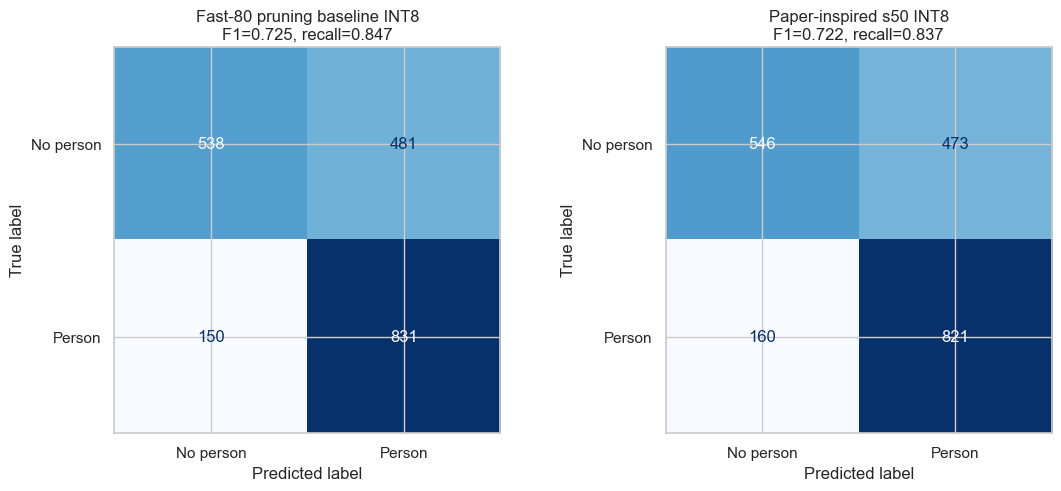

artifacts/pruning/unstructured_magnitude/figures/test_confusion_matrices_revised.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
for ax, title, metrics in [
    (axes[0], "Fast-80 pruning baseline INT8", baseline_test_metrics),
    (axes[1], f"Paper-inspired {SELECTED_TAG} INT8", selected_test_metrics),
]:
    ConfusionMatrixDisplay(confusion_matrix=np.asarray(metrics["confusion_matrix"]), display_labels=["No person", "Person"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{title}\nF1={metrics['f1']:.3f}, recall={metrics['recall']:.3f}")
figure_path = FIGURE_DIR / "test_confusion_matrices_revised.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 27 · Account for dense work and theoretical sparse work separately

In [27]:
baseline_layer_lookup = baseline_layers.set_index("layer_name")


def theoretical_nonzero_macs(model: tf.keras.Model) -> int:
    total = 0
    for layer in prunable_layers(model):
        nonzeros = int(np.count_nonzero(np.asarray(layer.kernel.numpy())))
        if isinstance(layer, tf.keras.layers.Dense):
            reuse = 1
        else:
            profile = baseline_layer_lookup.loc[layer.name]
            reuse = int(profile["output_height"] * profile["output_width"])
        total += nonzeros * reuse
    return total


resource_rows = []
for export in exports.itertuples(index=False):
    if export.strategy == "baseline":
        model = baseline_model
        sparsity = 0.0
    else:
        prefix = "one_shot" if export.strategy == "one_shot_global" else "iterative"
        model = tf.keras.models.load_model(MODEL_DIR / f"{prefix}_{export.tag}_recovered.keras", compile=False)
        sparsity = measured_kernel_sparsity(model)
    total_weights = int(prunable_inventory["kernel_weights"].sum())
    nonzeros = int(round(total_weights * (1 - sparsity)))
    resource_rows.append({
        "export_key": export.export_key,
        "strategy": export.strategy,
        "tag": export.tag,
        "target_sparsity": export.target_sparsity,
        "kernel_sparsity": sparsity,
        "kernel_nonzeros": nonzeros,
        "physical_parameters": reference_contract["float_parameters"],
        "dense_executed_macs": reference_contract["dense_macs_batch1"],
        "theoretical_nonzero_macs": theoretical_nonzero_macs(model),
        "tflite_live_activation_peak_bytes": reference_contract["tflite_live_activation_peak_bytes"],
        "tflite_bytes": export.tflite_bytes,
        "gzip_bytes": export.gzip_bytes,
        "bitmap_packed_kernel_bytes": math.ceil(total_weights / 8) + nonzeros,
        "index16_packed_kernel_bytes": nonzeros * 3 + (len(prunable_inventory) + 1) * 4,
        "operators": export.operators,
    })
    if export.strategy != "baseline":
        del model
resources = pd.DataFrame(resource_rows)
resources["theoretical_mac_reduction"] = 1 - resources["theoretical_nonzero_macs"] / resources["dense_executed_macs"]
resources.to_csv(REPORT_DIR / "resource_comparison_revised.csv", index=False)
display(resources.style.hide(axis="index").format({
    "target_sparsity": "{:.0%}", "kernel_sparsity": "{:.1%}", "kernel_nonzeros": "{:,}", "physical_parameters": "{:,}",
    "dense_executed_macs": "{:,}", "theoretical_nonzero_macs": "{:,}", "tflite_live_activation_peak_bytes": "{:,}",
    "tflite_bytes": "{:,}", "gzip_bytes": "{:,}", "bitmap_packed_kernel_bytes": "{:,}", "index16_packed_kernel_bytes": "{:,}",
    "theoretical_mac_reduction": "{:.1%}"
}))

export_key,strategy,tag,target_sparsity,kernel_sparsity,kernel_nonzeros,physical_parameters,dense_executed_macs,theoretical_nonzero_macs,tflite_live_activation_peak_bytes,tflite_bytes,gzip_bytes,bitmap_packed_kernel_bytes,index16_packed_kernel_bytes,operators,theoretical_mac_reduction
baseline__s00,baseline,s00,0%,0.0%,"104,944","111,793","3,993,536","3,993,536","38,400","167,976","125,325","118,062","314,924",7,0.0%
one_shot_global__s25,one_shot_global,s25,25%,25.0%,"78,708","111,793","3,993,536","3,316,329","38,400","167,976","112,332","91,826","236,216",7,17.0%
one_shot_global__s50,one_shot_global,s50,50%,50.0%,"52,472","111,793","3,993,536","2,558,443","38,400","167,976","92,368","65,590","157,508",7,35.9%
one_shot_global__s75,one_shot_global,s75,75%,75.0%,"26,236","111,793","3,993,536","1,687,741","38,400","167,976","63,943","39,354","78,800",7,57.7%
one_shot_global__s90,one_shot_global,s90,90%,90.0%,"10,495","111,793","3,993,536","1,021,938","38,400","167,976","41,000","23,613","31,577",7,74.4%
paper_iterative__s25,paper_iterative,s25,25%,25.0%,"78,708","111,793","3,993,536","3,500,504","38,400","167,976","111,949","91,826","236,216",7,12.3%
paper_iterative__s50,paper_iterative,s50,50%,50.0%,"52,472","111,793","3,993,536","2,935,819","38,400","167,976","90,900","65,590","157,508",7,26.5%
paper_iterative__s75,paper_iterative,s75,75%,75.0%,"26,236","111,793","3,993,536","2,253,095","38,400","167,976","60,922","39,354","78,800",7,43.6%
paper_iterative__s90,paper_iterative,s90,90%,90.0%,"10,495","111,793","3,993,536","1,661,650","38,400","166,816","37,128","23,613","31,577",7,58.4%


## 28 · Run a controlled host timing check without calling it an ESP32 result

In [28]:
first_image = np.asarray(next(iter(val_ds))[0][0])


def benchmark_host_tflite(model_path: Path) -> dict[str, float]:
    interpreter = tf.lite.Interpreter(model_path=str(model_path), num_threads=1)
    interpreter.allocate_tensors()
    input_detail = interpreter.get_input_details()[0]
    scale, zero = input_detail["quantization"]
    quantized = np.clip(np.round(first_image / scale + zero), -128, 127).astype(np.int8)[None, ...]
    interpreter.set_tensor(input_detail["index"], quantized)
    for _ in range(HOST_WARMUPS):
        interpreter.invoke()
    samples = []
    for _ in range(HOST_RUNS):
        started = time.perf_counter_ns()
        interpreter.invoke()
        samples.append((time.perf_counter_ns() - started) / 1e6)
    return {"host_median_ms": float(np.median(samples)), "host_p95_ms": float(np.percentile(samples, 95))}


host_timings = pd.DataFrame([
    {"export_key": row.export_key, "strategy": row.strategy, "tag": row.tag, **benchmark_host_tflite(ROOT / row.tflite_path)}
    for row in exports.itertuples(index=False)
])
host_timings.to_csv(REPORT_DIR / "host_tflite_timings_revised.csv", index=False)
display(host_timings.style.hide(axis="index").format({"host_median_ms": "{:.3f}", "host_p95_ms": "{:.3f}"}))

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


export_key,strategy,tag,host_median_ms,host_p95_ms
baseline__s00,baseline,s00,0.077,0.081
one_shot_global__s25,one_shot_global,s25,0.078,0.088
one_shot_global__s50,one_shot_global,s50,0.077,0.087
one_shot_global__s75,one_shot_global,s75,0.077,0.084
one_shot_global__s90,one_shot_global,s90,0.077,0.088
paper_iterative__s25,paper_iterative,s25,0.077,0.088
paper_iterative__s50,paper_iterative,s50,0.077,0.083
paper_iterative__s75,paper_iterative,s75,0.077,0.091
paper_iterative__s90,paper_iterative,s90,0.077,0.090


## 29 · Visualize storage formats instead of treating gzip as deployed flash

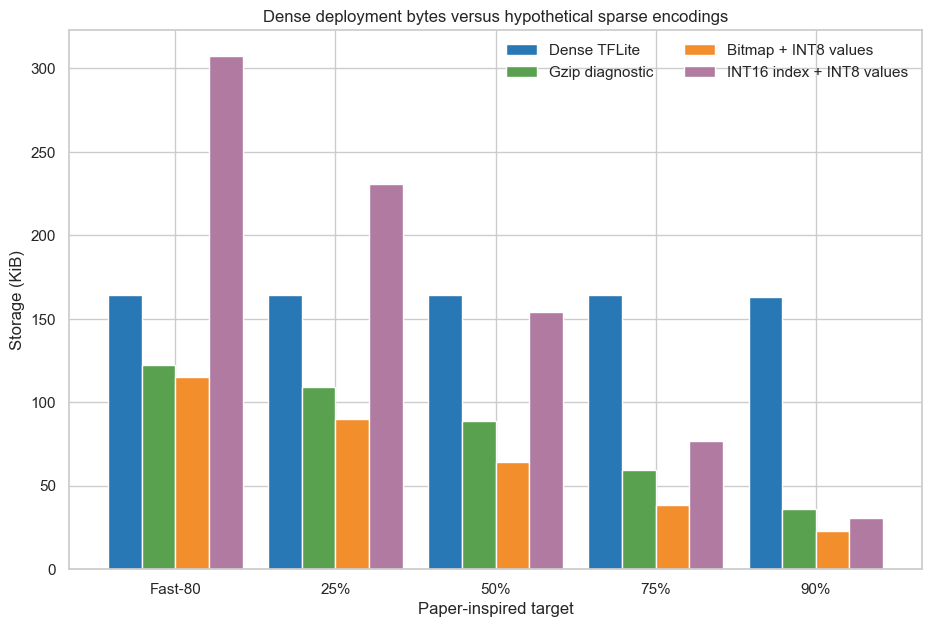

artifacts/pruning/unstructured_magnitude/figures/sparse_storage_encodings.png


In [29]:
storage_plot = resources[resources["strategy"].isin(["baseline", "paper_iterative"])].sort_values("target_sparsity")
fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(len(storage_plot))
width = 0.21
ax.bar(x - 1.5 * width, storage_plot["tflite_bytes"] / 1024, width, label="Dense TFLite", color="#2878B5")
ax.bar(x - 0.5 * width, storage_plot["gzip_bytes"] / 1024, width, label="Gzip diagnostic", color="#59A14F")
ax.bar(x + 0.5 * width, storage_plot["bitmap_packed_kernel_bytes"] / 1024, width, label="Bitmap + INT8 values", color="#F28E2B")
ax.bar(x + 1.5 * width, storage_plot["index16_packed_kernel_bytes"] / 1024, width, label="INT16 index + INT8 values", color="#B07AA1")
ax.set(title="Dense deployment bytes versus hypothetical sparse encodings", xlabel="Paper-inspired target", ylabel="Storage (KiB)", xticks=x, xticklabels=["Fast-80"] + [f"{int(v * 100)}%" for v in storage_plot["target_sparsity"].iloc[1:]])
ax.legend(frameon=False, ncol=2)
figure_path = FIGURE_DIR / "sparse_storage_encodings.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 30 · Visualize quality, storage, compute, and activation honestly

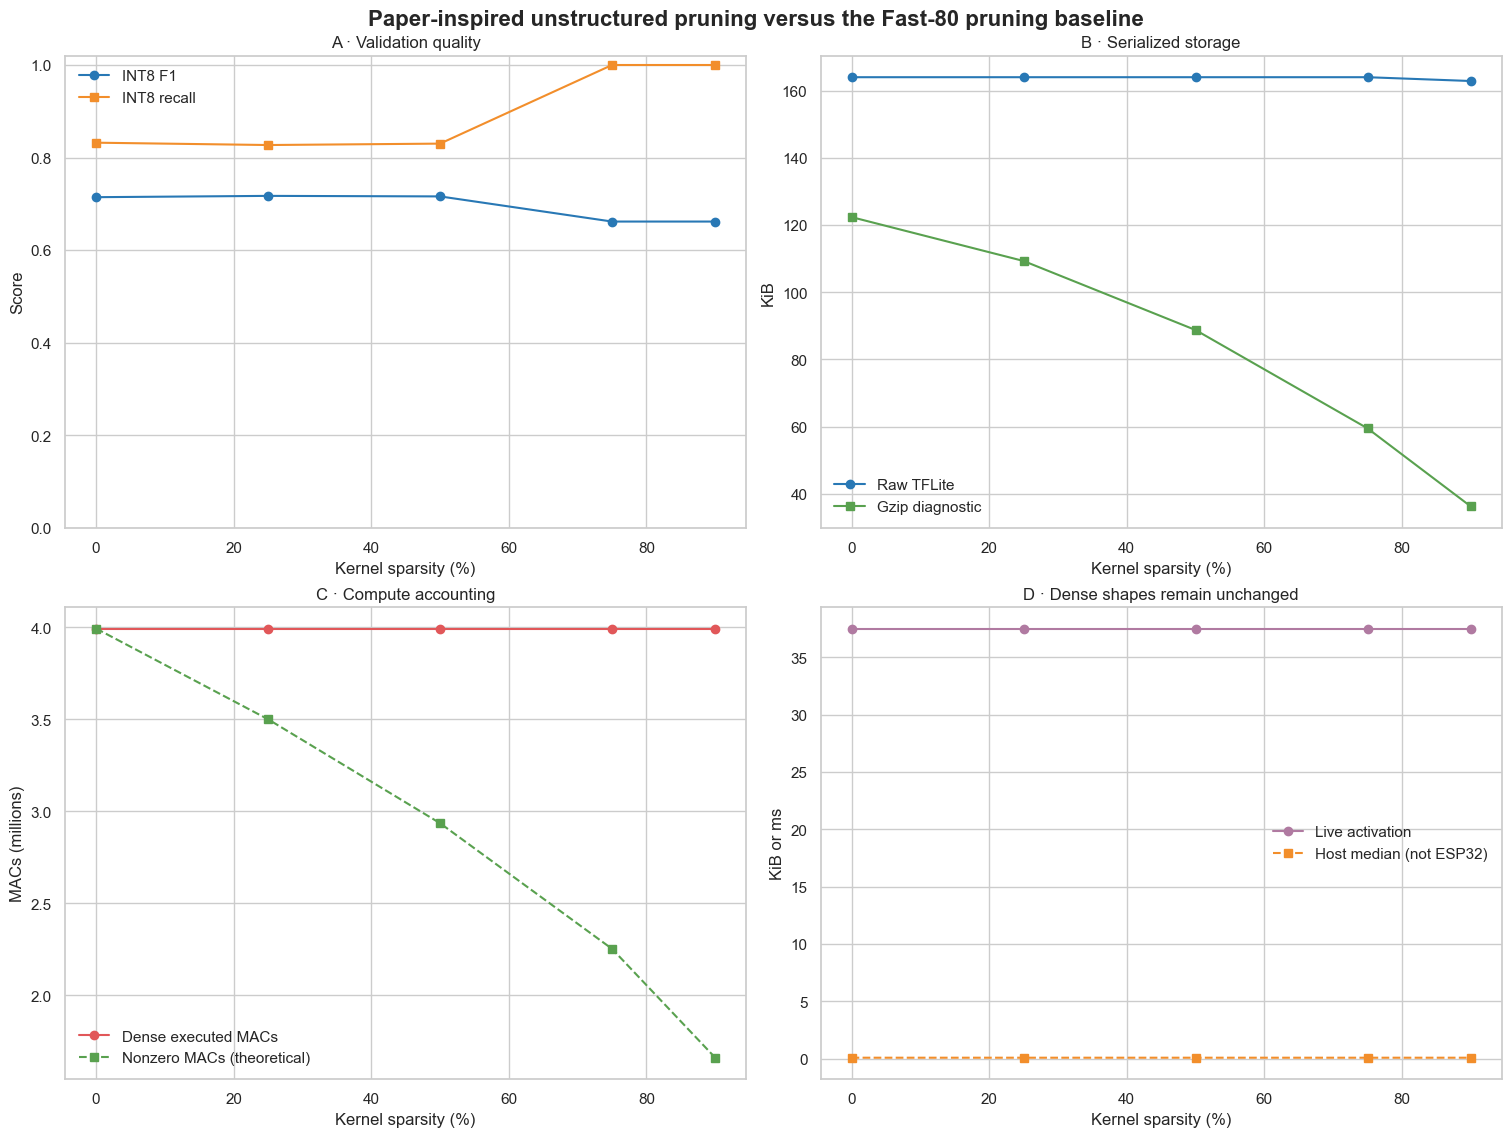

artifacts/pruning/unstructured_magnitude/figures/efficiency_dashboard_revised.png


In [30]:
comparison = resources.merge(int8_metrics[["export_key", "f1", "recall", "pr_auc"]], on="export_key").merge(host_timings[["export_key", "host_median_ms"]], on="export_key")
comparison = comparison[comparison["strategy"].isin(["baseline", "paper_iterative"])].sort_values("target_sparsity")
x = comparison["target_sparsity"] * 100
fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
axes[0, 0].plot(x, comparison["f1"], "o-", label="INT8 F1", color="#2878B5")
axes[0, 0].plot(x, comparison["recall"], "s-", label="INT8 recall", color="#F28E2B")
axes[0, 0].set(title="A · Validation quality", xlabel="Kernel sparsity (%)", ylabel="Score", ylim=(0, 1.02))
axes[0, 0].legend(frameon=False)
axes[0, 1].plot(x, comparison["tflite_bytes"] / 1024, "o-", label="Raw TFLite", color="#2878B5")
axes[0, 1].plot(x, comparison["gzip_bytes"] / 1024, "s-", label="Gzip diagnostic", color="#59A14F")
axes[0, 1].set(title="B · Serialized storage", xlabel="Kernel sparsity (%)", ylabel="KiB")
axes[0, 1].legend(frameon=False)
axes[1, 0].plot(x, comparison["dense_executed_macs"] / 1e6, "o-", label="Dense executed MACs", color="#E15759")
axes[1, 0].plot(x, comparison["theoretical_nonzero_macs"] / 1e6, "s--", label="Nonzero MACs (theoretical)", color="#59A14F")
axes[1, 0].set(title="C · Compute accounting", xlabel="Kernel sparsity (%)", ylabel="MACs (millions)")
axes[1, 0].legend(frameon=False)
axes[1, 1].plot(x, comparison["tflite_live_activation_peak_bytes"] / 1024, "o-", label="Live activation", color="#B07AA1")
axes[1, 1].plot(x, comparison["host_median_ms"], "s--", label="Host median (not ESP32)", color="#F28E2B")
axes[1, 1].set(title="D · Dense shapes remain unchanged", xlabel="Kernel sparsity (%)", ylabel="KiB or ms")
axes[1, 1].legend(frameon=False)
fig.suptitle("Paper-inspired unstructured pruning versus the Fast-80 pruning baseline", fontsize=16, weight="bold", y=1.02)
figure_path = FIGURE_DIR / "efficiency_dashboard_revised.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(figure_path.relative_to(ROOT))

## 31 · Load the exact selected-model ESP32 profile when available

In [31]:
DEVICE_VARIANT = f"prune_unstructured_iterative_{SELECTED_TAG}"
candidate_device_dir = ROOT / "artifacts/device_profiles" / DEVICE_VARIANT
candidate_device_summary_path = candidate_device_dir / "device_profile_summary.json"
baseline_device_summary_path = BASELINE_DEVICE_DIR / "device_profile_summary.json"
device_profile_available = candidate_device_summary_path.exists() and baseline_device_summary_path.exists()
device_profile_command = (
    "source scripts/activate_esp_idf.sh && "
    f"scripts/profile_esp32_model.sh {SELECTED_TFLITE_PATH.relative_to(ROOT)} 80 {DEVICE_VARIANT} /dev/cu.usbserial-120"
)
if device_profile_available:
    print(f"Physical profile found: {candidate_device_dir.relative_to(ROOT)}")
else:
    print("Physical profile pending. Run:")
    print(device_profile_command)

Physical profile found: artifacts/device_profiles/prune_unstructured_iterative_s50


## 32 · Compare complete physical resource evidence

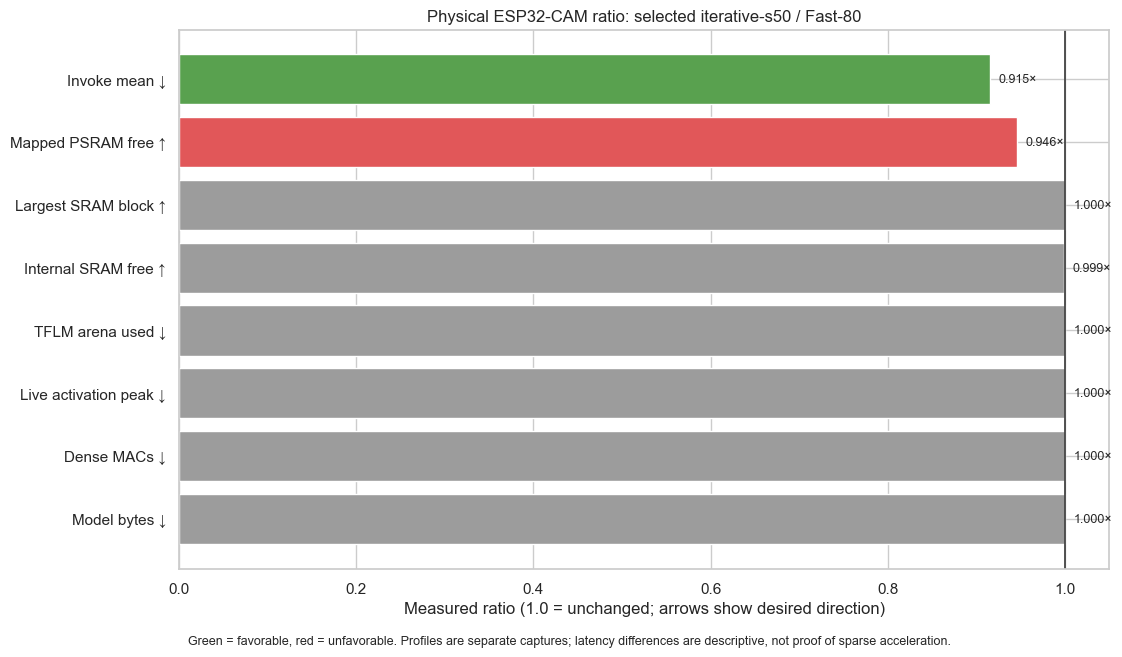

metric,key,unit,direction,baseline,candidate,candidate_over_baseline
Model bytes ↓,model_bytes,B,lower,"167,976.000","167,976.000",1.000×
Dense MACs ↓,estimated_macs,MAC,lower,"3,993,536.000","3,993,536.000",1.000×
Live activation peak ↓,tflite_live_activation_peak_bytes,B,lower,"38,400.000","38,400.000",1.000×
TFLM arena used ↓,arena_used_bytes,B,lower,"69,068.000","69,068.000",1.000×
Internal SRAM free ↑,ready_internal_free_bytes,B,higher,"66,867.000","66,799.000",0.999×
Largest SRAM block ↑,ready_internal_largest_bytes,B,higher,"61,440.000","61,440.000",1.000×
Mapped PSRAM free ↑,ready_psram_free_bytes,B,higher,"3,387,184.000","3,202,860.000",0.946×
Invoke mean ↓,mean_us,µs,lower,"455,546.400","416,804.900",0.915×


In [32]:
device_comparison = pd.DataFrame()
if device_profile_available:
    with baseline_device_summary_path.open(encoding="utf-8") as handle:
        baseline_device = json.load(handle)
    with candidate_device_summary_path.open(encoding="utf-8") as handle:
        candidate_device = json.load(handle)
    device_metrics = [
        ("Model bytes ↓", "model_bytes", "B", "lower"),
        ("Dense MACs ↓", "estimated_macs", "MAC", "lower"),
        ("Live activation peak ↓", "tflite_live_activation_peak_bytes", "B", "lower"),
        ("TFLM arena used ↓", "arena_used_bytes", "B", "lower"),
        ("Internal SRAM free ↑", "ready_internal_free_bytes", "B", "higher"),
        ("Largest SRAM block ↑", "ready_internal_largest_bytes", "B", "higher"),
        ("Mapped PSRAM free ↑", "ready_psram_free_bytes", "B", "higher"),
        ("Invoke mean ↓", "mean_us", "µs", "lower"),
    ]
    rows = []
    for label, key, unit, direction in device_metrics:
        if key in baseline_device and key in candidate_device:
            rows.append({"metric": label, "key": key, "unit": unit, "direction": direction, "baseline": baseline_device[key], "candidate": candidate_device[key], "candidate_over_baseline": candidate_device[key] / baseline_device[key]})
    pipeline_keys = [
        ("Preprocess median ↓", "pipeline_preprocess_median_ms", "ms", "lower"),
        ("Active pipeline median ↓", "pipeline_active_median_ms", "ms", "lower"),
        ("Frame period median ↓", "pipeline_period_median_ms", "ms", "lower"),
        ("Complete pipeline FPS ↑", "pipeline_fps_median", "fps", "higher"),
    ]
    for label, key, unit, direction in pipeline_keys:
        if key in baseline_device and key in candidate_device:
            rows.append({"metric": label, "key": key, "unit": unit, "direction": direction, "baseline": baseline_device[key], "candidate": candidate_device[key], "candidate_over_baseline": candidate_device[key] / baseline_device[key]})
    device_comparison = pd.DataFrame(rows)
    device_comparison.to_csv(REPORT_DIR / "physical_device_comparison.csv", index=False)
    fig, ax = plt.subplots(figsize=(12, 7))
    ratios = device_comparison["candidate_over_baseline"]
    favorable = [
        (ratio < 0.995 if direction == "lower" else ratio > 1.005)
        for ratio, direction in zip(ratios, device_comparison["direction"])
    ]
    unfavorable = [
        (ratio > 1.005 if direction == "lower" else ratio < 0.995)
        for ratio, direction in zip(ratios, device_comparison["direction"])
    ]
    colors_physical = [
        "#59A14F" if is_favorable else "#E15759" if is_unfavorable else "#9C9C9C"
        for is_favorable, is_unfavorable in zip(favorable, unfavorable)
    ]
    bars = ax.barh(device_comparison["metric"], ratios, color=colors_physical)
    ax.axvline(1.0, color="#444444", linewidth=1.3)
    ax.set(title="Physical ESP32-CAM ratio: selected iterative-s50 / Fast-80", xlabel="Measured ratio (1.0 = unchanged; arrows show desired direction)", ylabel="")
    for bar, ratio in zip(bars, ratios):
        ax.text(ratio + 0.01, bar.get_y() + bar.get_height() / 2, f"{ratio:.3f}×", va="center", fontsize=9)
    ax.text(0.01, -0.14, "Green = favorable, red = unfavorable. Profiles are separate captures; latency differences are descriptive, not proof of sparse acceleration.", transform=ax.transAxes, fontsize=9)
    figure_path = FIGURE_DIR / "physical_esp32_comparison.png"
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.show()
    display(device_comparison.style.hide(axis="index").format({"baseline": "{:,.3f}", "candidate": "{:,.3f}", "candidate_over_baseline": "{:.3f}×"}))
else:
    display(Markdown("**Physical-device status: pending.** No ESP32 speed or memory claim is made until the exact selected FlatBuffer is captured."))

## 33 · Write the corrected experiment report

In [33]:
selected_resource = resources.set_index("export_key").loc[SELECTED_EXPORT_KEY]
baseline_resource = resources[resources["strategy"] == "baseline"].iloc[0]
head_rows = layer_sparsity[layer_sparsity["layer"] == "person_probability"].pivot(index="tag", columns="strategy", values="layer_sparsity")
if device_profile_available:
    invoke_delta = 100 * (candidate_device["mean_us"] / baseline_device["mean_us"] - 1)
    physical_lines = [
        f"- Exact selected-model profile: `{candidate_device_dir.relative_to(ROOT)}`.",
        f"- Batch 1, {int(candidate_device['samples'])} measured invokes after {int(candidate_device['warmup'])} warm-ups.",
        "",
        "| Metric | Fast-80 | Iterative-s50 | Change |",
        "|---|---:|---:|---:|",
        f"| Full Invoke mean | {baseline_device['mean_us'] / 1000:.3f} ms | {candidate_device['mean_us'] / 1000:.3f} ms | {invoke_delta:+.1f}% |",
        f"| TFLM arena used | {int(baseline_device['arena_used_bytes']):,} B | {int(candidate_device['arena_used_bytes']):,} B | {int(candidate_device['arena_used_bytes'] - baseline_device['arena_used_bytes']):+,} B |",
        f"| Live activation peak | {int(baseline_device['tflite_live_activation_peak_bytes']):,} B | {int(candidate_device['tflite_live_activation_peak_bytes']):,} B | {int(candidate_device['tflite_live_activation_peak_bytes'] - baseline_device['tflite_live_activation_peak_bytes']):+,} B |",
        f"| Dense MACs executed | {int(baseline_device['estimated_macs']):,} | {int(candidate_device['estimated_macs']):,} | unchanged |",
        f"| Model bytes | {int(baseline_device['model_bytes']):,} B | {int(candidate_device['model_bytes']):,} B | unchanged |",
        "",
        f"- Candidate live pipeline: {candidate_device.get('pipeline_fps_median', float('nan')):.2f} fps, {candidate_device.get('pipeline_preprocess_median_ms', float('nan')):.1f} ms median preprocessing, and {candidate_device.get('pipeline_period_median_ms', float('nan')):.1f} ms median frame period.",
        "- The observed Invoke difference comes from separate physical capture sessions. Because the FlatBuffer shapes, dense MAC count, and arena are unchanged, it must not be attributed to unstructured zeros without repeated alternating trials or a sparse ESP-NN kernel.",
        "- White flash was compiled in but disabled with `kFlashLedEnabled = false`; boot confirmed GPIO4 was forced low.",
    ]
else:
    physical_lines = [f"Pending. Run `{device_profile_command}`."]
report_lines = [
    "# Unstructured magnitude pruning report — revised",
    "",
    "## Method contract",
    "",
    "- Fast-80 is the frozen pruning baseline.",
    "- Global one-shot is retained as the negative control.",
    f"- Paper-inspired branch uses {ITERATIVE_ROUNDS} prune/retrain rounds, sensitivity-adjusted magnitude, and Adam {ITERATIVE_LEARNING_RATE:g}.",
    "- This is a Fast-80 adaptation of Han et al., not an exact AlexNet/VGG reproduction.",
    f"- Selected candidate: `{SELECTED_EXPORT_KEY}` ({SELECTED_SPARSITY:.0%}) — {selection_reason}.",
    "- Selection and thresholds use validation only; held-out test is opened after selection.",
    "",
    "## Held-out full-INT8 test",
    "",
    "| Model | Threshold | Accuracy | Precision | Recall | Specificity | F1 | PR-AUC |",
    "|---|---:|---:|---:|---:|---:|---:|---:|",
    f"| Fast-80 pruning baseline | {baseline_test_metrics['threshold']:.3f} | {baseline_test_metrics['accuracy']:.3f} | {baseline_test_metrics['precision']:.3f} | {baseline_test_metrics['recall']:.3f} | {baseline_test_metrics['specificity']:.3f} | {baseline_test_metrics['f1']:.3f} | {baseline_test_metrics['pr_auc']:.3f} |",
    f"| Paper-inspired {SELECTED_TAG} | {selected_test_metrics['threshold']:.3f} | {selected_test_metrics['accuracy']:.3f} | {selected_test_metrics['precision']:.3f} | {selected_test_metrics['recall']:.3f} | {selected_test_metrics['specificity']:.3f} | {selected_test_metrics['f1']:.3f} | {selected_test_metrics['pr_auc']:.3f} |",
    "",
    "## Efficiency interpretation",
    "",
    f"- Kernel sparsity: {selected_resource['kernel_sparsity']:.1%}.",
    f"- Raw TFLite: {int(selected_resource['tflite_bytes']):,} B versus {int(baseline_resource['tflite_bytes']):,} B controlled re-export.",
    f"- Gzip diagnostic: {int(selected_resource['gzip_bytes']):,} B versus {int(baseline_resource['gzip_bytes']):,} B.",
    f"- Bitmap + INT8 values estimate: {int(selected_resource['bitmap_packed_kernel_bytes']):,} B for kernels only.",
    f"- Theoretical nonzero MACs: {int(selected_resource['theoretical_nonzero_macs']):,}.",
    f"- Dense executed MACs remain {int(selected_resource['dense_executed_macs']):,}; activation peak remains {int(selected_resource['tflite_live_activation_peak_bytes']):,} B.",
    "- Sparse acceleration still requires a compatible storage format and custom sparse ESP-NN kernels.",
    "",
    "## Physical ESP32-CAM profile",
    "",
    *physical_lines,
    "",
    "## Next technique",
    "",
    "Notebook 14 is pattern-based pruning, following the granularity sequence in the pruning plan.",
]
report_path = OUTPUT_DIR / "UNSTRUCTURED_MAGNITUDE_REPORT.md"
report_path.write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print(report_path.relative_to(ROOT))

artifacts/pruning/unstructured_magnitude/UNSTRUCTURED_MAGNITUDE_REPORT.md


## 34 · Record a machine-readable artifact manifest

In [34]:
generated_files = sorted(path for path in OUTPUT_DIR.rglob("*") if path.is_file())
manifest = {
    "notebook": "optimization/pruning/13_unstructured_magnitude_pruning.ipynb",
    "technique": "global one-shot control plus sensitivity-adjusted iterative unstructured magnitude pruning",
    "primary_reference": "Han et al. 2015, Learning both Weights and Connections",
    "seed": SEED,
    "sparsity_levels": list(SPARSITY_LEVELS),
    "iterative_rounds": ITERATIVE_ROUNDS,
    "selected_export_key": SELECTED_EXPORT_KEY,
    "selected_sparsity": SELECTED_SPARSITY,
    "selection_reason": selection_reason,
    "physical_device_profile_available": bool(device_profile_available),
    "physical_device_variant": DEVICE_VARIANT,
    "flash_led_enabled_during_profile": False,
    "frozen_input_hashes": current_hashes,
    "selected_float_sha256": sha256_file(SELECTED_FLOAT_PATH),
    "selected_tflite_sha256": sha256_file(SELECTED_TFLITE_PATH),
    "generated_artifacts": [
        {"path": str(path.relative_to(ROOT)), "bytes": path.stat().st_size, "sha256": sha256_file(path)}
        for path in generated_files
        if path.name != "artifact_manifest.json" and path.suffix != ".keras"
    ],
}
manifest_path = OUTPUT_DIR / "artifact_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
print({"selected": SELECTED_EXPORT_KEY, "physical_profile": device_profile_available, "artifacts": len(manifest["generated_artifacts"])})

{'selected': 'paper_iterative__s50', 'physical_profile': True, 'artifacts': 72}


## 35 · Findings and hand-off

In [35]:
device_sentence = (
    f"Physical ESP32 profile: {candidate_device['mean_us'] / 1000:.3f} ms mean Invoke, "
    f"{int(candidate_device['arena_used_bytes']):,} B arena used, and "
    f"{candidate_device.get('pipeline_fps_median', float('nan')):.2f} fps; dense shapes remain unchanged."
    if device_profile_available
    else "Physical ESP32 capture is still required before a latency or memory conclusion."
)
conclusion = (
    f"**Notebook 13 revised: `{SELECTED_EXPORT_KEY}` selected at {SELECTED_SPARSITY:.0%} sparsity.**\n\n"
    f"- Held-out INT8 F1: **{selected_test_metrics['f1']:.3f}** versus **{baseline_test_metrics['f1']:.3f}** for the controlled Fast-80 re-export.\n"
    f"- Recall: **{selected_test_metrics['recall']:.3f}**; PR-AUC: **{selected_test_metrics['pr_auc']:.3f}**.\n"
    f"- Raw TFLite: **{int(selected_resource['tflite_bytes']):,} B**; dense MACs: **{int(selected_resource['dense_executed_macs']):,}**; live activation: **{int(selected_resource['tflite_live_activation_peak_bytes']):,} B**.\n"
    f"- Theoretical nonzero MACs: **{int(selected_resource['theoretical_nonzero_macs']):,}**; this is not a dense ESP-NN speed claim.\n"
    f"- {device_sentence}\n"
    "- **Next granularity:** Notebook 14, pattern-based pruning."
)
display(Markdown(conclusion))

**Notebook 13 revised: `paper_iterative__s50` selected at 50% sparsity.**

- Held-out INT8 F1: **0.722** versus **0.725** for the controlled Fast-80 re-export.
- Recall: **0.837**; PR-AUC: **0.781**.
- Raw TFLite: **167,976 B**; dense MACs: **3,993,536**; live activation: **38,400 B**.
- Theoretical nonzero MACs: **2,935,819**; this is not a dense ESP-NN speed claim.
- Physical ESP32 profile: 416.805 ms mean Invoke, 69,068 B arena used, and 1.68 fps; dense shapes remain unchanged.
- **Next granularity:** Notebook 14, pattern-based pruning.